<a href="https://colab.research.google.com/github/TowsifTazwar/data-science-research/blob/main/9_DecisiontreeKNNLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Datasets/cybersecurity_intrusion_data.csv')
print(f"Shape: {df.shape}")
df.head()

Mounted at /content/drive
Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [3]:
print("Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nClass Distribution")
print(df["attack_detected"].value_counts())

df.info()

Shape: (9537, 11)

Missing Values
session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

Class Distribution
attack_detected
0    5273
1    4264
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   f

In [4]:
df = df.drop(columns=["session_id"])

df.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [5]:
for col in df.columns:

    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum())

network_packet_size    0
protocol_type          0
login_attempts         0
session_duration       0
encryption_used        0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
dtype: int64


/tmp/ipykernel_744/1357903112.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_744/1357903112.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [11]:
## Encoding

encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,1,4,492.983263,1,0.606818,1,1,0,1
1,472,1,3,1557.996461,1,0.301569,0,2,0,0
2,629,1,3,75.044262,1,0.739164,2,0,0,1
3,804,2,4,601.248835,1,0.123267,0,4,0,1
4,453,1,5,532.540888,0,0.054874,1,2,0,0


In [12]:
X = df.drop("attack_detected", axis=1)
y = df["attack_detected"]

print(X.shape)
print(y.shape)

(9537, 9)
(9537,)


In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
## Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7629, 9)
(1908, 9)


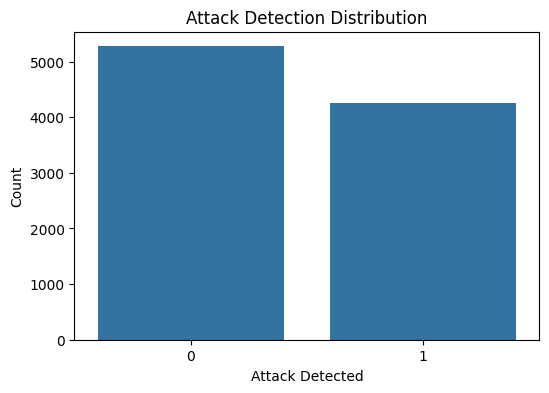

In [15]:
## EDA

plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Attack Detection Distribution")
plt.xlabel("Attack Detected")
plt.ylabel("Count")

plt.show()

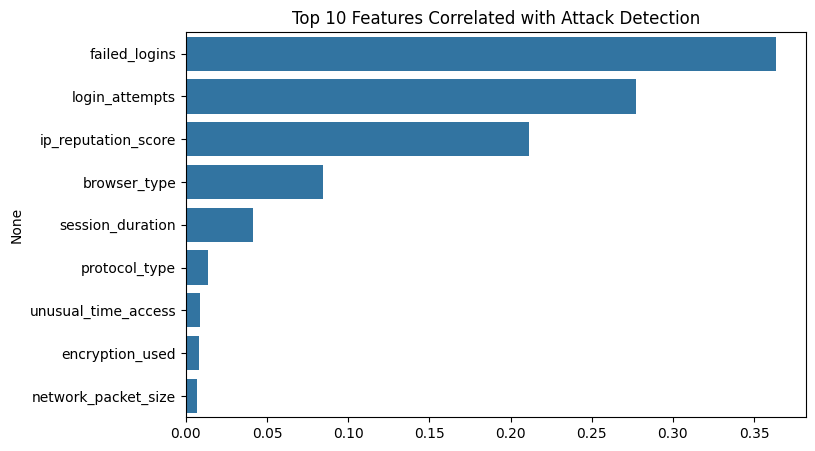

In [16]:
## Top 10 Feature Correlations

corr = df.corr()

target_corr = corr["attack_detected"].drop("attack_detected")

top10 = target_corr.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Features Correlated with Attack Detection")

plt.show()

In [17]:
## Train Decision Tree

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [18]:
## Train KNN

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [19]:
## Train Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [20]:
## Model Evaluation

results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "KNN",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, lr_pred)
    ],

    "Precision":[
        precision_score(y_test, dt_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, lr_pred)
    ],

    "Recall":[
        recall_score(y_test, dt_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, lr_pred)
    ],

    "F1 Score":[
        f1_score(y_test, dt_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, lr_pred)
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.813941,0.790210,0.794842,0.792519
1,KNN,0.807128,0.873652,0.664713,0.754993
2,Logistic Regression,0.722746,0.706633,0.649472,0.676848


In [21]:
## Decision Tree Depth Tuning

depths = [3,5,10,15,20,None]

depth_results = []

for d in depths:

    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    depth_results.append([

        str(d),

        accuracy_score(y_test,pred),

        precision_score(y_test,pred),

        recall_score(y_test,pred),

        f1_score(y_test,pred)

    ])

depth_df = pd.DataFrame(

    depth_results,

    columns=[
        "Max Depth",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

)

depth_df

,Max Depth,Accuracy,Precision,Recall,F1 Score
0,3,0.864256,1.000000,0.696366,0.821009
1,5,0.884172,1.000000,0.740914,0.851178
2,10,0.881027,0.983025,0.746776,0.848767
3,15,0.870021,0.940320,0.757327,0.838961
4,20,0.848008,0.867974,0.778429,0.820766
5,None,0.813941,0.790210,0.794842,0.792519


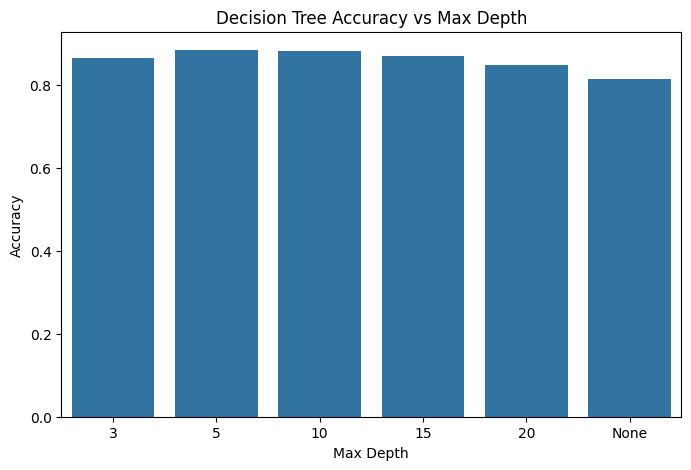

In [22]:
## Depth Tuning Bar Chart

plt.figure(figsize=(8,5))

sns.barplot(
    x="Max Depth",
    y="Accuracy",
    data=depth_df
)

plt.title("Decision Tree Accuracy vs Max Depth")

plt.show()

In [23]:
## Classification Report

print("Decision Tree")
print(classification_report(y_test, dt_pred))

print("="*60)

print("KNN")
print(classification_report(y_test, knn_pred))

print("="*60)

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1055
           1       0.79      0.79      0.79       853

    accuracy                           0.81      1908
   macro avg       0.81      0.81      0.81      1908
weighted avg       0.81      0.81      0.81      1908

KNN
              precision    recall  f1-score   support

           0       0.77      0.92      0.84      1055
           1       0.87      0.66      0.75       853

    accuracy                           0.81      1908
   macro avg       0.82      0.79      0.80      1908
weighted avg       0.82      0.81      0.80      1908

Logistic Regression
              precision    recall  f1-score   support

           0       0.73      0.78      0.76      1055
           1       0.71      0.65      0.68       853

    accuracy                           0.72      1908
   macro avg       0.72      0.72      0.72      1908
weighted avg       0.72      0.72   

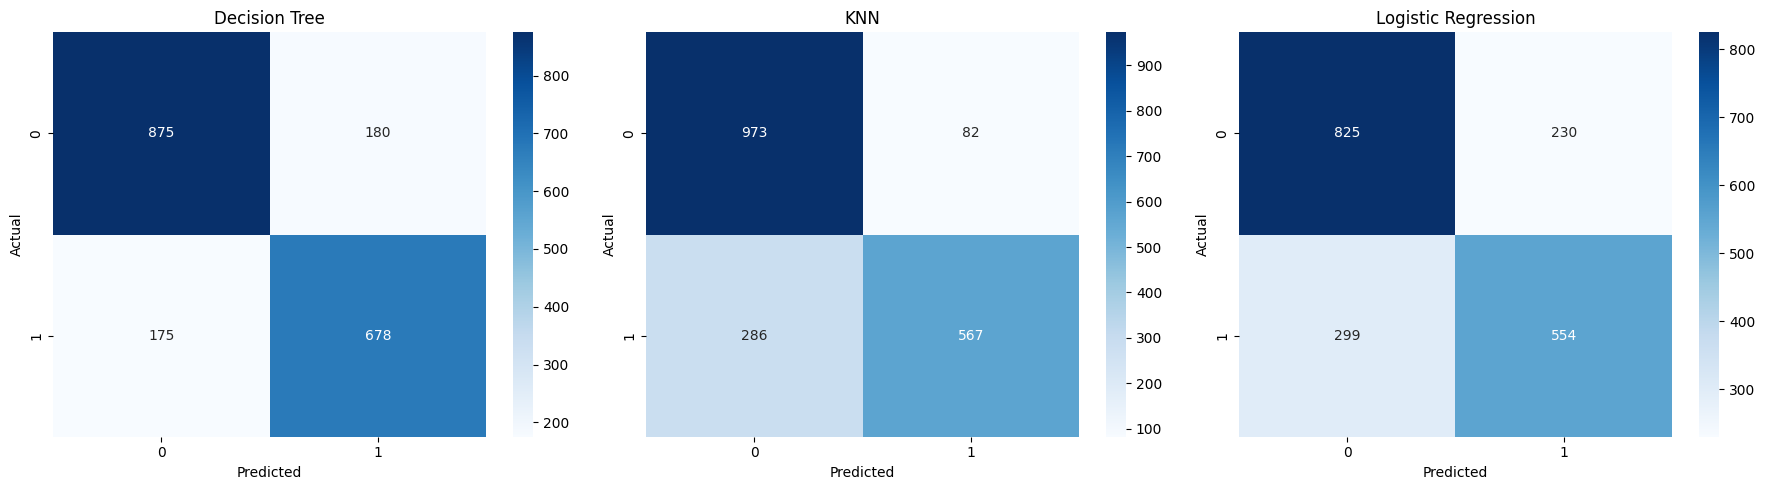

In [24]:
## Confusion Matrix

fig, axes = plt.subplots(1,3,figsize=(18,5))

models = [
    ("Decision Tree", dt_pred),
    ("KNN", knn_pred),
    ("Logistic Regression", lr_pred)
]

for ax, (name, pred) in zip(axes, models):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()

plt.show()

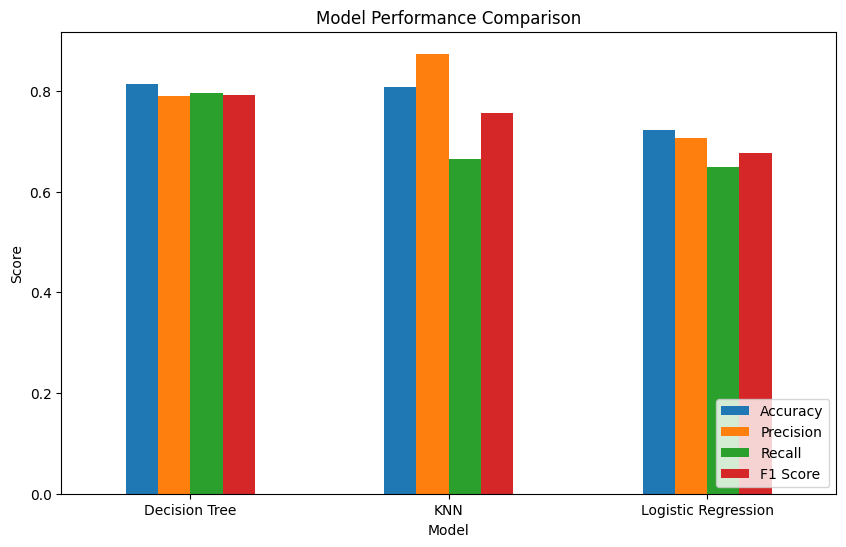

In [25]:
## Model Comparison Bar Chart

results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.show()